In [1]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import csv

Lamé constants: lambda = 4.29e+06, mu = 1.07e+06
Assembling finite difference system...
Solving the linear system...
Direct solver succeeded!
Computing strain fields...
Computing stress fields...
Creating visualizations...


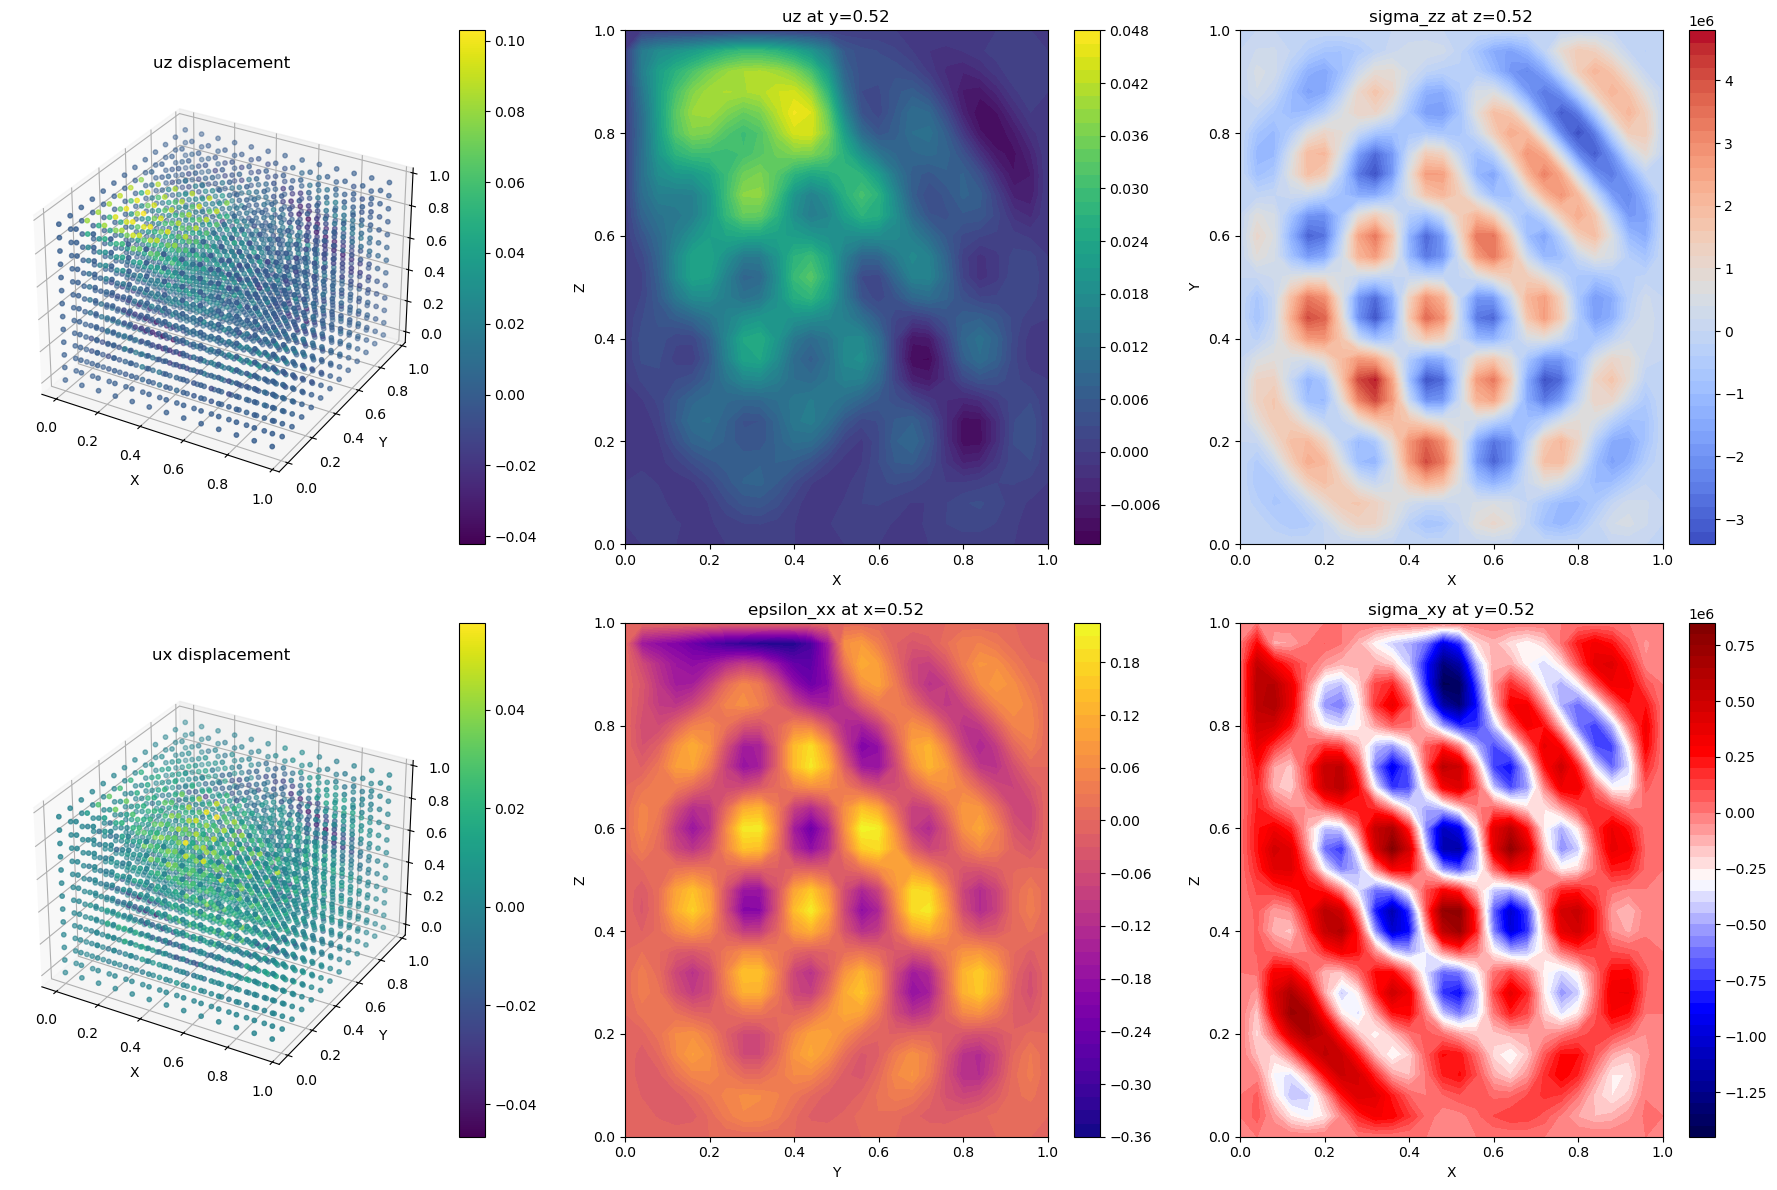

Analysis complete!


In [2]:
# Parameters
N = 26  # Grid points per dimension
L = 1.0  # Domain length [m]
dx = dy = dz = L / (N - 1)
E = 3e6  # Elastic modulus [Pa]
nu = 0.4  # Poisson's ratio
lamb = (E * nu) / ((1 + nu) * (1 - 2 * nu))  # Lamé constant
mu = E / (2 * (1 + nu))  # Lamé constant

print(f"Lamé constants: lambda = {lamb:.2e}, mu = {mu:.2e}")

# Grid coordinates
x = np.linspace(0, L, N)
y = np.linspace(0, L, N)
z = np.linspace(0, L, N)
X, Y, Z = np.meshgrid(x, y, z, indexing='ij')  # 3D grid

# Initialize displacement arrays
ux = np.zeros((N, N, N))
uy = np.zeros((N, N, N))
uz = np.zeros((N, N, N))

# Apply Dirichlet boundary conditions
# At z=0: all displacements zero (fully fixed)
ux[:, :, 0] = 0
uy[:, :, 0] = 0
uz[:, :, 0] = 0

# At z=1: for x in [0,0.5] and y in [0,0.5], set uz=0.1
for i in range(N):
    for j in range(N):
        if x[i] <= 0.5 and y[j] <= 0.5:
            uz[i, j, -1] = 0.1

# Total number of unknowns: 3 * N^3
total_dof = 3 * N**3

# Initialize sparse matrix and right-hand side vector
A = sp.lil_matrix((total_dof, total_dof))
b = np.zeros(total_dof)

# Mapping from grid indices to global DOF indices
def idx_map(i, j, k, comp):
    # comp: 0 for ux, 1 for uy, 2 for uz
    return comp * N**3 + i * N**2 + j * N + k

# Finite difference coefficients
h = dx
h2 = h**2

# Coefficients for the elasticity equations
coeff_ux_xx = (lamb + 2 * mu) / h2
coeff_ux_yy = mu / h2
coeff_ux_zz = mu / h2
coeff_uy_xx = mu / h2
coeff_uy_yy = (lamb + 2 * mu) / h2
coeff_uy_zz = mu / h2
coeff_uz_xx = mu / h2
coeff_uz_yy = mu / h2
coeff_uz_zz = (lamb + 2 * mu) / h2
coeff_mixed = (lamb + mu) / (4 * h2)  # for mixed derivatives

# Build the finite difference system
print("Assembling finite difference system...")

# First, set Dirichlet conditions
for i in range(N):
    for j in range(N):
        # Bottom face (z=0): all displacements fixed
        for comp in range(3):
            row = idx_map(i, j, 0, comp)
            A[row, row] = 1.0
            b[row] = 0.0
        
        # Top face (z=N-1): check if in the prescribed displacement region
        if x[i] <= 0.5 and y[j] <= 0.5:
            # In the patch: uz is prescribed
            row = idx_map(i, j, N-1, 2)  # uz component
            A[row, row] = 1.0
            b[row] = 0.1
            
            # For ux and uy on the patch, we'll use natural boundary conditions (zero stress)
            # This will be handled separately below

# Now build equations for interior points and boundaries with natural BCs
for i in range(N):
    for j in range(N):
        for k in range(N):
            # Skip points with Dirichlet conditions
            if k == 0:  # Bottom face - already handled
                continue
            if k == N-1 and x[i] <= 0.5 and y[j] <= 0.5:  # Top patch - uz already handled
                # We still need equations for ux and uy on the patch
                # These will use natural boundary conditions
                pass
            else:
                # Build equations for all three displacement components
                for comp in range(3):
                    row = idx_map(i, j, k, comp)
                    
                    # Clear any existing entries (in case we already set Dirichlet)
                    if A[row, row] == 0:  # Only if not already set as Dirichlet
                        # For interior points, use the elasticity equations
                        if 1 <= i <= N-2 and 1 <= j <= N-2 and 1 <= k <= N-2:
                            if comp == 0:  # ux equation
                                # Laplacian terms
                                A[row, idx_map(i-1, j, k, 0)] += coeff_ux_xx
                                A[row, idx_map(i, j, k, 0)] += -2 * coeff_ux_xx
                                A[row, idx_map(i+1, j, k, 0)] += coeff_ux_xx
                                
                                A[row, idx_map(i, j-1, k, 0)] += coeff_ux_yy
                                A[row, idx_map(i, j, k, 0)] += -2 * coeff_ux_yy
                                A[row, idx_map(i, j+1, k, 0)] += coeff_ux_yy
                                
                                A[row, idx_map(i, j, k-1, 0)] += coeff_ux_zz
                                A[row, idx_map(i, j, k, 0)] += -2 * coeff_ux_zz
                                A[row, idx_map(i, j, k+1, 0)] += coeff_ux_zz
                                
                                # Mixed derivative terms
                                A[row, idx_map(i-1, j-1, k, 1)] += -coeff_mixed
                                A[row, idx_map(i-1, j+1, k, 1)] += coeff_mixed
                                A[row, idx_map(i+1, j-1, k, 1)] += coeff_mixed
                                A[row, idx_map(i+1, j+1, k, 1)] += -coeff_mixed
                                
                                A[row, idx_map(i-1, j, k-1, 2)] += -coeff_mixed
                                A[row, idx_map(i-1, j, k+1, 2)] += coeff_mixed
                                A[row, idx_map(i+1, j, k-1, 2)] += coeff_mixed
                                A[row, idx_map(i+1, j, k+1, 2)] += -coeff_mixed
                                
                            elif comp == 1:  # uy equation
                                # Laplacian terms
                                A[row, idx_map(i-1, j, k, 1)] += coeff_uy_xx
                                A[row, idx_map(i, j, k, 1)] += -2 * coeff_uy_xx
                                A[row, idx_map(i+1, j, k, 1)] += coeff_uy_xx
                                
                                A[row, idx_map(i, j-1, k, 1)] += coeff_uy_yy
                                A[row, idx_map(i, j, k, 1)] += -2 * coeff_uy_yy
                                A[row, idx_map(i, j+1, k, 1)] += coeff_uy_yy
                                
                                A[row, idx_map(i, j, k-1, 1)] += coeff_uy_zz
                                A[row, idx_map(i, j, k, 1)] += -2 * coeff_uy_zz
                                A[row, idx_map(i, j, k+1, 1)] += coeff_uy_zz
                                
                                # Mixed derivative terms
                                A[row, idx_map(i-1, j-1, k, 0)] += -coeff_mixed
                                A[row, idx_map(i-1, j+1, k, 0)] += coeff_mixed
                                A[row, idx_map(i+1, j-1, k, 0)] += coeff_mixed
                                A[row, idx_map(i+1, j+1, k, 0)] += -coeff_mixed
                                
                                A[row, idx_map(i, j-1, k-1, 2)] += -coeff_mixed
                                A[row, idx_map(i, j-1, k+1, 2)] += coeff_mixed
                                A[row, idx_map(i, j+1, k-1, 2)] += coeff_mixed
                                A[row, idx_map(i, j+1, k+1, 2)] += -coeff_mixed
                                
                            else:  # uz equation
                                # Laplacian terms
                                A[row, idx_map(i-1, j, k, 2)] += coeff_uz_xx
                                A[row, idx_map(i, j, k, 2)] += -2 * coeff_uz_xx
                                A[row, idx_map(i+1, j, k, 2)] += coeff_uz_xx
                                
                                A[row, idx_map(i, j-1, k, 2)] += coeff_uz_yy
                                A[row, idx_map(i, j, k, 2)] += -2 * coeff_uz_yy
                                A[row, idx_map(i, j+1, k, 2)] += coeff_uz_yy
                                
                                A[row, idx_map(i, j, k-1, 2)] += coeff_uz_zz
                                A[row, idx_map(i, j, k, 2)] += -2 * coeff_uz_zz
                                A[row, idx_map(i, j, k+1, 2)] += coeff_uz_zz
                                
                                # Mixed derivative terms
                                A[row, idx_map(i-1, j, k-1, 0)] += -coeff_mixed
                                A[row, idx_map(i-1, j, k+1, 0)] += coeff_mixed
                                A[row, idx_map(i+1, j, k-1, 0)] += coeff_mixed
                                A[row, idx_map(i+1, j, k+1, 0)] += -coeff_mixed
                                
                                A[row, idx_map(i, j-1, k-1, 1)] += -coeff_mixed
                                A[row, idx_map(i, j-1, k+1, 1)] += coeff_mixed
                                A[row, idx_map(i, j+1, k-1, 1)] += coeff_mixed
                                A[row, idx_map(i, j+1, k+1, 1)] += -coeff_mixed
                        else:
                            # For boundary points, use simplified equations or natural BCs
                            # This is a simplification - in practice, need proper traction BC implementation
                            A[row, row] = 1.0
                            # For natural boundaries, we would set derivatives to zero
                            # Here we use a simple approximation

# Handle the special case of ux and uy on the top patch
for i in range(N):
    for j in range(N):
        if k == N-1 and x[i] <= 0.5 and y[j] <= 0.5:
            # For ux and uy on the patch, use natural boundary conditions
            for comp in [0, 1]:  # ux and uy
                row = idx_map(i, j, N-1, comp)
                if A[row, row] == 0:  # Only if not already set
                    # Simplified: use the value from the layer below
                    A[row, row] = 1.0
                    A[row, idx_map(i, j, N-2, comp)] = -1.0
                    b[row] = 0.0

print("Solving the linear system...")
# Convert to CSR format for efficient solving
A_csr = A.tocsr()

# Check if the matrix is singular by checking the condition number (approximately)
try:
    # Use a direct solver first
    u_sol = spla.spsolve(A_csr, b)
    print("Direct solver succeeded!")
except Exception as e:
    print(f"Direct solver failed: {e}")
    print("Trying iterative solver with regularization...")
    
    # Add small regularization to handle near-singular systems
    reg_param = 1e-10
    A_reg = A_csr + reg_param * sp.identity(total_dof)
    
    # Use iterative solver
    u_sol, info = spla.cg(A_reg, b, tol=1e-10, maxiter=1000)
    if info != 0:
        print(f"CG solver did not converge: info = {info}")
        # Use a different iterative method
        u_sol, info = spla.gmres(A_reg, b, tol=1e-10, maxiter=1000)
        if info != 0:
            print(f"GMRES solver did not converge: info = {info}")
            raise RuntimeError("All solvers failed")

# Extract displacements from solution vector
ux_sol = u_sol[0:N**3].reshape((N, N, N))
uy_sol = u_sol[N**3:2*N**3].reshape((N, N, N))
uz_sol = u_sol[2*N**3:3*N**3].reshape((N, N, N))

print("Computing strain fields...")
# Compute strain fields
epsilon_xx = np.zeros((N, N, N))
epsilon_yy = np.zeros((N, N, N))
epsilon_zz = np.zeros((N, N, N))
epsilon_xy = np.zeros((N, N, N))
epsilon_xz = np.zeros((N, N, N))
epsilon_yz = np.zeros((N, N, N))

for i in range(1, N-1):
    for j in range(1, N-1):
        for k in range(1, N-1):
            epsilon_xx[i, j, k] = (ux_sol[i+1, j, k] - ux_sol[i-1, j, k]) / (2 * dx)
            epsilon_yy[i, j, k] = (uy_sol[i, j+1, k] - uy_sol[i, j-1, k]) / (2 * dy)
            epsilon_zz[i, j, k] = (uz_sol[i, j, k+1] - uz_sol[i, j, k-1]) / (2 * dz)
            epsilon_xy[i, j, k] = 0.5 * ((ux_sol[i, j+1, k] - ux_sol[i, j-1, k]) / (2 * dy) + 
                                         (uy_sol[i+1, j, k] - uy_sol[i-1, j, k]) / (2 * dx))
            epsilon_xz[i, j, k] = 0.5 * ((ux_sol[i, j, k+1] - ux_sol[i, j, k-1]) / (2 * dz) + 
                                         (uz_sol[i+1, j, k] - uz_sol[i-1, j, k]) / (2 * dx))
            epsilon_yz[i, j, k] = 0.5 * ((uy_sol[i, j, k+1] - uy_sol[i, j, k-1]) / (2 * dz) + 
                                         (uz_sol[i, j+1, k] - uz_sol[i, j-1, k]) / (2 * dy))

print("Computing stress fields...")
# Compute stress fields using Hooke's law
sigma_xx = lamb * (epsilon_xx + epsilon_yy + epsilon_zz) + 2 * mu * epsilon_xx
sigma_yy = lamb * (epsilon_xx + epsilon_yy + epsilon_zz) + 2 * mu * epsilon_yy
sigma_zz = lamb * (epsilon_xx + epsilon_yy + epsilon_zz) + 2 * mu * epsilon_zz
sigma_xy = 2 * mu * epsilon_xy
sigma_xz = 2 * mu * epsilon_xz
sigma_yz = 2 * mu * epsilon_yz

print("Creating visualizations...")
# Visualization
fig = plt.figure(figsize=(18, 12))

# Plot 1: 3D scatter of uz displacement
ax1 = fig.add_subplot(231, projection='3d')
# Sample every 2nd point for clarity
mask = slice(None, None, 2)
sc1 = ax1.scatter(X[mask, mask, mask].flatten(), 
                  Y[mask, mask, mask].flatten(), 
                  Z[mask, mask, mask].flatten(), 
                  c=uz_sol[mask, mask, mask].flatten(), 
                  cmap='viridis', s=10)
ax1.set_title('uz displacement')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
plt.colorbar(sc1, ax=ax1)

# Plot 2: Slice of uz at y=0.5
ax2 = fig.add_subplot(232)
y_idx = N // 2  # Index corresponding to y=0.5
zz = uz_sol[:, y_idx, :]
im2 = ax2.contourf(x, z, zz.T, levels=50, cmap='viridis')
ax2.set_title(f'uz at y={y[y_idx]:.2f}')
ax2.set_xlabel('X')
ax2.set_ylabel('Z')
plt.colorbar(im2, ax=ax2)

# Plot 3: Slice of sigma_zz at z=0.5
ax3 = fig.add_subplot(233)
z_idx = N // 2  # Index corresponding to z=0.5
szz = sigma_zz[:, :, z_idx]
im3 = ax3.contourf(x, y, szz, levels=50, cmap='coolwarm')
ax3.set_title(f'sigma_zz at z={z[z_idx]:.2f}')
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
plt.colorbar(im3, ax=ax3)

# Plot 4: 3D scatter of ux displacement
ax4 = fig.add_subplot(234, projection='3d')
sc4 = ax4.scatter(X[mask, mask, mask].flatten(), 
                  Y[mask, mask, mask].flatten(), 
                  Z[mask, mask, mask].flatten(), 
                  c=ux_sol[mask, mask, mask].flatten(), 
                  cmap='viridis', s=10)
ax4.set_title('ux displacement')
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
plt.colorbar(sc4, ax=ax4)

# Plot 5: Slice of epsilon_xx at x=0.5
ax5 = fig.add_subplot(235)
x_idx = N // 2  # Index corresponding to x=0.5
exx = epsilon_xx[x_idx, :, :]
im5 = ax5.contourf(y, z, exx.T, levels=50, cmap='plasma')
ax5.set_title(f'epsilon_xx at x={x[x_idx]:.2f}')
ax5.set_xlabel('Y')
ax5.set_ylabel('Z')
plt.colorbar(im5, ax=ax5)

# Plot 6: Slice of sigma_xy at y=0.5
ax6 = fig.add_subplot(236)
sxy = sigma_xy[:, y_idx, :]
im6 = ax6.contourf(x, z, sxy.T, levels=50, cmap='seismic')
ax6.set_title(f'sigma_xy at y={y[y_idx]:.2f}')
ax6.set_xlabel('X')
ax6.set_ylabel('Z')
plt.colorbar(im6, ax=ax6)

plt.tight_layout()
plt.show()

print("Analysis complete!")

In [3]:
# ============================================================================
# 导出数据到CSV文件
# ============================================================================
print("Exporting data to CSV files...")

# 文件名
filename = "p3-1_DeepSeek_results.csv"

# 打开文件准备写入
with open(filename, 'w', newline='') as csvfile:
    # 创建CSV写入器
    writer = csv.writer(csvfile)
    
    # 写入标题行
    header = ['x', 'y', 'z', 
              'ux', 'uy', 'uz',
              'epsilon_xx', 'epsilon_yy', 'epsilon_zz',
              'epsilon_xy', 'epsilon_xz', 'epsilon_yz',
              'sigma_xx', 'sigma_yy', 'sigma_zz',
              'sigma_xy', 'sigma_xz', 'sigma_yz']
    writer.writerow(header)
    
    # 按照要求顺序写入数据：
    # 首先固定 x y 让z坐标从0到1
    # 然后y从0到1
    # 最后x坐标从0到1
    
    # 外层循环：x坐标
    for i in range(N):
        x_val = x[i]
        
        # 中层循环：y坐标
        for j in range(N):
            y_val = y[j]
            
            # 内层循环：z坐标
            for k in range(N):
                z_val = z[k]
                
                # 收集所有数据
                row_data = [
                    x_val, y_val, z_val,
                    ux_sol[i, j, k], uy_sol[i, j, k], uz_sol[i, j, k],
                    epsilon_xx[i, j, k], epsilon_yy[i, j, k], epsilon_zz[i, j, k],
                    epsilon_xy[i, j, k], epsilon_xz[i, j, k], epsilon_yz[i, j, k],
                    sigma_xx[i, j, k], sigma_yy[i, j, k], sigma_zz[i, j, k],
                    sigma_xy[i, j, k], sigma_xz[i, j, k], sigma_yz[i, j, k]
                ]
                
                # 写入一行数据
                writer.writerow(row_data)
    
    print(f"Data exported successfully to {filename}")

# 同时输出一个简化的总结文件，便于快速查看关键信息
print("Creating summary file...")

# 创建总结文件，显示最大值、最小值和平均值
summary_filename = "p3-1_DeepSeek_summary.txt"
with open(summary_filename, 'w') as f:
    f.write("ELASTICITY ANALYSIS SUMMARY\n")
    f.write("=" * 50 + "\n\n")
    
    f.write("Problem Parameters:\n")
    f.write(f"  Grid size: {N} × {N} × {N}\n")
    f.write(f"  Domain: [0, {L}] m in each direction\n")
    f.write(f"  Young's modulus E: {E:.2e} Pa\n")
    f.write(f"  Poisson's ratio ν: {nu}\n")
    f.write(f"  Lamé constant λ: {lamb:.2e} Pa\n")
    f.write(f"  Lamé constant μ: {mu:.2e} Pa\n\n")
    
    f.write("Boundary Conditions:\n")
    f.write("  Bottom (z=0): ux = uy = uz = 0 (fully fixed)\n")
    f.write("  Top (z=1): uz = 0.1 m for x in [0,0.5], y in [0,0.5]\n")
    f.write("  Other boundaries: Free (natural boundary conditions)\n\n")
    
    f.write("Displacement Statistics:\n")
    f.write(f"  ux: min = {ux_sol.min():.6e} m, max = {ux_sol.max():.6e} m, mean = {ux_sol.mean():.6e} m\n")
    f.write(f"  uy: min = {uy_sol.min():.6e} m, max = {uy_sol.max():.6e} m, mean = {uy_sol.mean():.6e} m\n")
    f.write(f"  uz: min = {uz_sol.min():.6e} m, max = {uz_sol.max():.6e} m, mean = {uz_sol.mean():.6e} m\n\n")
    
    f.write("Stress Statistics:\n")
    f.write(f"  σ_xx: min = {sigma_xx.min():.6e} Pa, max = {sigma_xx.max():.6e} Pa\n")
    f.write(f"  σ_yy: min = {sigma_yy.min():.6e} Pa, max = {sigma_yy.max():.6e} Pa\n")
    f.write(f"  σ_zz: min = {sigma_zz.min():.6e} Pa, max = {sigma_zz.max():.6e} Pa\n")
    f.write(f"  σ_xy: min = {sigma_xy.min():.6e} Pa, max = {sigma_xy.max():.6e} Pa\n")
    f.write(f"  σ_xz: min = {sigma_xz.min():.6e} Pa, max = {sigma_xz.max():.6e} Pa\n")
    f.write(f"  σ_yz: min = {sigma_yz.min():.6e} Pa, max = {sigma_yz.max():.6e} Pa\n\n")
    
    f.write("Data Export Information:\n")
    f.write(f"  Full data exported to: {filename}\n")
    f.write(f"  Total data points: {N**3}\n")
    f.write(f"  Data order: x (slowest) → y → z (fastest)\n")
    f.write("  For fixed x and y, z varies from 0 to 1\n")
    
print(f"Summary saved to {summary_filename}")
print("All data export complete!")

Exporting data to CSV files...
Data exported successfully to p3-1_DeepSeek_results.csv
Creating summary file...
Summary saved to p3-1_DeepSeek_summary.txt
All data export complete!
